## 12.2 `scipy.optimize`: solving equations, minimizing functions
### `scipy.optimize.root_scalar`:
This is a general function to solve equations of the form $f(x) = 0$ using one of several root-finding algorithms (including bisection, Newton, secant, ...) See the documentation [here](`https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html#root-scalar#scipy.optimize.root_scalar)

Calling sequence:  `scipy.optimize.root_scalar(f, args=(), method=None, bracket=None, fprime=None, fprime2=None, x0=None, x1=None, xtol=None, rtol=None, maxiter=None)`

* `f` should return the value of the function, or the function and its first (and possibly second) derivative in a tuple
* `args` is as in integrate
* `method` is optional. Possible values include `bisect`, `newton`, `secant`, `brentq` (which combines sall three of these methods).
* `bracket` is a bracketing interval of a solution
* `x0` is an initial guess
* `x1` is a second guess
* If `fprime` is `True`, `f` is expected to return the function and its first derivative
* If `fprime2` is `True`, `f` is expected to return the function and its first and second derivative
* `xtol`, `rtol`, `maxiter` are respectively the desired accuracy on the root, the value of the function and the number of iterations to perform.
`scipy.optimize.root_scalar` returns a [`RootResults` object ](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.RootResults.html#scipy.optimize.RootResults)

`scipy.optimize.root_scalar` will pick a method depending on the arguments that are provided 


In [12]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
%matplotlib widget

In [13]:
def f(x):
    return np.sinc(x)

scipy.optimize.root_scalar(f, x0=3.5)
      converged: True
           flag: converged
 function_calls: 6
     iterations: 3
           root: 7.000000000000001
         method: newton

scipy.optimize.root_scalar(f, bracket=[0,3.5], method='bisect')
      converged: True
           flag: converged
 function_calls: 43
     iterations: 41
           root: 0.9999999999997726
         method: bisect

scipy.optimize.root_scalar(f, bracket=[0,3.5], method='brentq')
      converged: True
           flag: converged
 function_calls: 10
     iterations: 9
           root: 3.0
         method: brentq


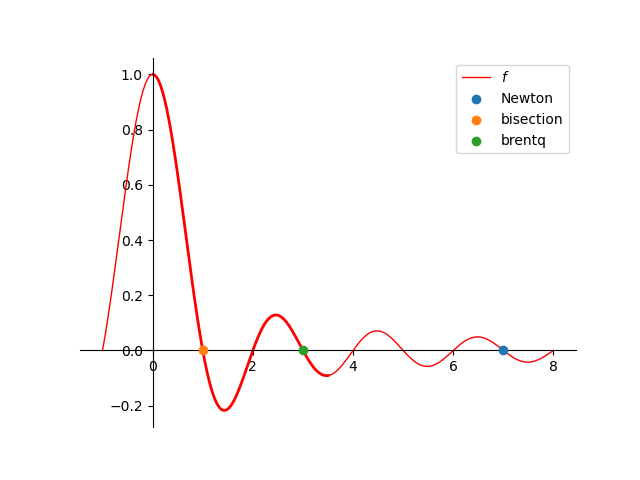

In [15]:
X = np.linspace(-1,8,501)
fig, ax = plt.subplots()
ax.plot(X,f(X), label='$f$', color = 'r', linewidth=1)
Xb = [x for x in X if 0 <= x <= 3.5]
ax.plot(Xb,f(Xb), color = 'r', linewidth=2)
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

print('scipy.optimize.root_scalar(f, x0=3.5)')
sol = scipy.optimize.root_scalar(f, x0=3.5)
print(sol)
ax.scatter([sol.root], [f(sol.root)],label='Newton', zorder = 10)

print("\nscipy.optimize.root_scalar(f, bracket=[0,3.5], method='bisect')")
sol = scipy.optimize.root_scalar(f, bracket=[0,3.5], method='bisect')
print(sol)
ax.scatter([sol.root], [f(sol.root)],label='bisection', zorder = 10)

print("\nscipy.optimize.root_scalar(f, bracket=[0,3.5], method='brentq')")
sol = scipy.optimize.root_scalar(f, bracket=[0,3.5], method='brentq')
print(sol)
ax.scatter([sol.root], [f(sol.root)],label = 'brentq', zorder = 10)

ax.legend()

### An application:
Given any $p \in \mathbb{R}$, let  $f_p(x) = \frac{x^2-1}{2} - p^2 \ln(x)$. We have $f_p(1) = 0$  and $f'_p(x) = x-p^2/x$ so that $f'_p(p) = 0$.
Given any $\ell > 0$, can we find p such that $f_p(p) = -4\ell^2$?

We have that $f_p(p) = \frac{p^2-1}{2}-p^2\ln(p)$, so we must solve $f_p(p) = \frac{p^2-1}{2}-p^2\ln(p) = 4\ell^2$ for any given $\ell$.

Let's use an interactor to get an idea of the solution of this problem:

interactive(children=(FloatSlider(value=1.5000000000000002, description='p', max=3.0, min=0.1), FloatSlider(va…

<function __main__.plotf(p, ell)>

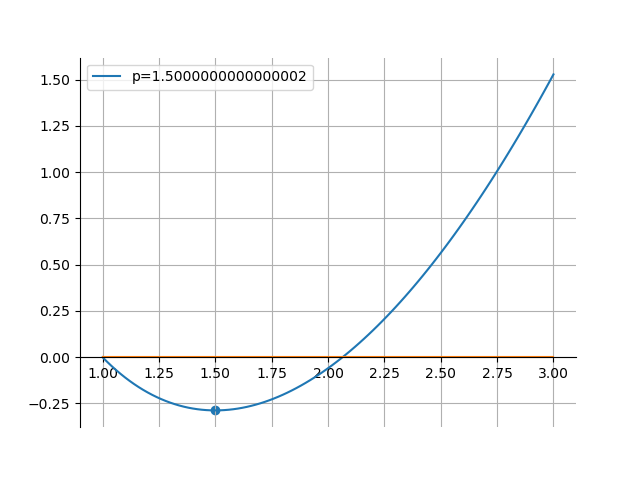

In [16]:
def f(p,x):
    return (x**2-1)/2 - p**2 * np.log(x)

from ipywidgets import interact

def plotf(p,ell):
    ax.cla()
    X=np.linspace(1,3,101)
    ax.plot(X,[f(p,x) for x in X],label = f'p={p}')
    ax.plot([X[0],X[-1]],[-4*ell**2,-4*ell**2])
    ax.scatter([p],[f(p,p)])
    # ax.axis([1,3,-5,5])
    ax.spines[['bottom']].set_position('zero')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid()
    ax.legend()

fig, ax = plt.subplots()
ax.grid()
interact(plotf, p=(0.1,3,0.1),ell = (0,1,0.1))

It looks like for $\ell = 1$, $p\in(2.5,3)$, and that for $\ell = 0.5$, $p \in (1.5,2)$. Let's find $p$ using `scipy.optimize.root_scalar`.



0.7127035067566301
-0.27258872223978114
      converged: True
           flag: converged
 function_calls: 8
     iterations: 7
           root: 1.895025455414376
         method: brentq
found p: 1.895025455414376, f(1.895025455414376,1.895025455414376) = -0.9999999999998983


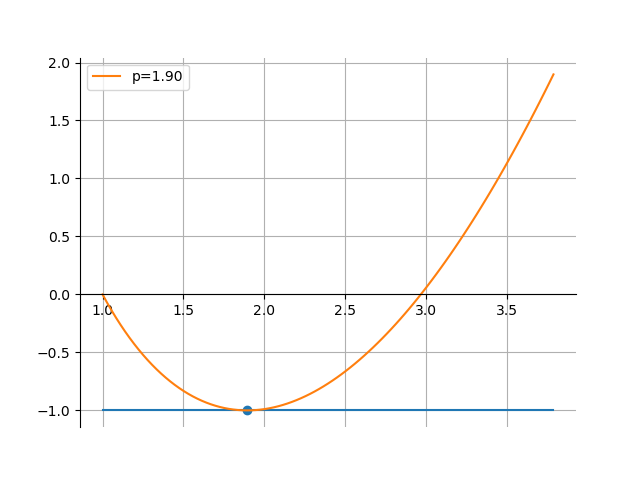

In [17]:
ell = 0.5
for p in (1.5,2):
    print(f(p,p)+4*ell**2)

sol = scipy.optimize.root_scalar(lambda p : f(p,p)+4*ell**2, bracket = (1.5,2))
print(sol)
print(f'found p: {sol.root}, f({sol.root},{sol.root}) = {f(sol.root,sol.root)}')

p = sol.root
fig, ax = plt.subplots()
X=np.linspace(1,2*p,101)
ax.plot([X[0],X[-1]],[-4*ell**2,-4*ell**2])
ax.plot(X,[f(p,x) for x in X],label = f'p={p:2.2f}')
ax.scatter([p],[f(p,p)])
ax.spines[['bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.grid()
ax.legend()


## Solving systems of linear equations
Consider a system of $n$ linear equations with $n$ unknowns:
$$
\begin{cases}
a_{11} x_1 + a_{12} x_2 + \dots + a_{1n} x_n & = & b_1\\
a_{21} x_1 + a_{22} x_2 + \dots + a_{2n} x_n & = & b_2\\
&  \vdots&  \\
a_{n1} x_1 + a_{n2} x_2 + \dots + a_{nn} x_n & = & b_n.
\end{cases}
$$
We can represent this linear system in terms of a two-dimensional array (a matrix)
$$
A = \begin{bmatrix}
a_{11} & a_{12} & \dots & a_{1n}\\
a_{21} & a_{22} & \dots & a_{2n}\\
\vdots & \vdots & & \vdots\\
a_{n1} & a_{n2} & \dots & a_{nn}
\end{bmatrix}
$$
and a one-dimensional array (a vector)
$$ b = \begin{bmatrix}
b_1\\
b_2\\
\vdots\\
b_n
\end{bmatrix}
$$

For those who know some linear algebra, we simply rewrote the system of equation as the matrix equation: $\mathrm{A} \mathbf{x} = \mathbf{b}$.

`scipy` can compute the solution of such system (when it exists!) provided that it is given the matrix $\mathrm{A}$ and the right hand side $\mathbf{b}$ as numpy ndarrays, using the `scipy.linalg.solve` function (we may discuss `scipy.linalg` a little bit more later).



Consider for instance
$$\begin{cases}
x + 2y + z & = 5\\
2x + 3y -z & = 8\\
x-y-z& =-1
\end{cases}
$$


In [18]:
A = np.array([[1,2,1],
              [2,3,-1],
              [1,-1,-1]])

b = np.array([5,8,-1])
x = np.linalg.solve(A,b)
print(x)

[ 1.00000000e+00  2.00000000e+00 -3.96508223e-17]


Consider a system of *non-linear* equations of the form
$$\begin{cases}
f_0(x,y) & = 0\\
f_1(x,y) & = 0
\end{cases}
$$
where $f_0$ and $f_1$ are two given functions.

`scipy.optimize.root` will try hard to solve this system of equations (but may not succeed).

For instance, let's try to find 2 numbers given their sum $S$ and product $P$.
We define $f(x,y) = (x+y-S, x*y-P)$ and try to solve f(x,y) = (0,0)$:

In [7]:
def f(x,S,P):
    return (x[0] + x[1] - S, x[0] * x[1] - P)
roots = scipy.optimize.root(f,(0.,0.),args=(3,2))
print(roots)

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00  0.000e+00]
       x: [ 2.000e+00  1.000e+00]
  method: hybr
    nfev: 18
    fjac: [[-7.414e-01 -6.711e-01]
           [ 6.711e-01 -7.414e-01]]
       r: [-1.349e+00 -2.020e+00 -7.414e-01]
     qtf: [-1.118e-10 -1.235e-10]


Notes that a better way to find these numbers is by solving the quadratic equation $x^2-Sx+P = 0$

In [8]:
from numpy.polynomial import Polynomial
S = 3
P = 2
p = Polynomial([P,-S,1])
print(p.roots())

[1. 2.]


## Finding extrema of functions

As indicated by its name, `scipy,optimize` is primarily designed to find extrema of functions. For function of a single variable, the main tool is `scipy.optimize.minimize_scalar`.

Let's find the extrema of the function $f(x) = (x-2)(x+1)^2$.

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: -4.0
       x: 1.0
     nit: 7
    nfev: 10


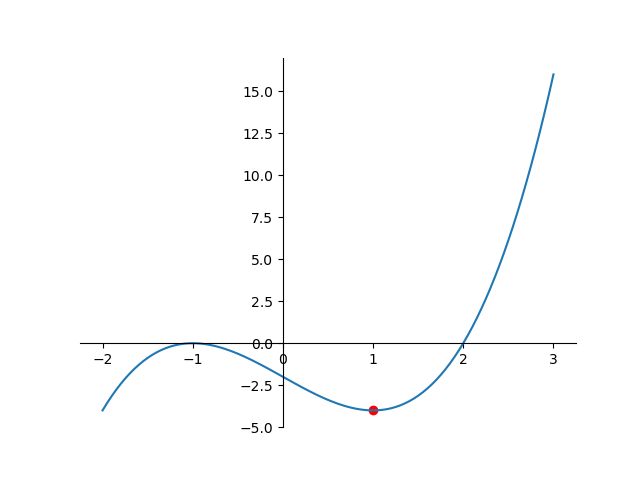

In [9]:
f = lambda x: (x - 2) * (x + 1)**2

fig, ax = plt.subplots()
X = np.linspace(-2,3,201)
ax.plot(X,f(X))
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

res = scipy.optimize.minimize_scalar(f)
plt.scatter(res.x, f(res.x),color='red')
print(res)

Note that 1 is *not* the *global* minimizer of this function (since $\lim_{x \to -\infty} f(x) = -\infty$ ), but only a *local* minimizer.

When a function admits multiple local minimizers, there is no way to make sure that the scheme will converge to the "best" one.

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 2.3063132757087517
       x: 0.8348319213728642
     nit: 12
    nfev: 15
 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: -5.159945770802011
       x: -2.123275673236978
     nit: 13
    nfev: 16


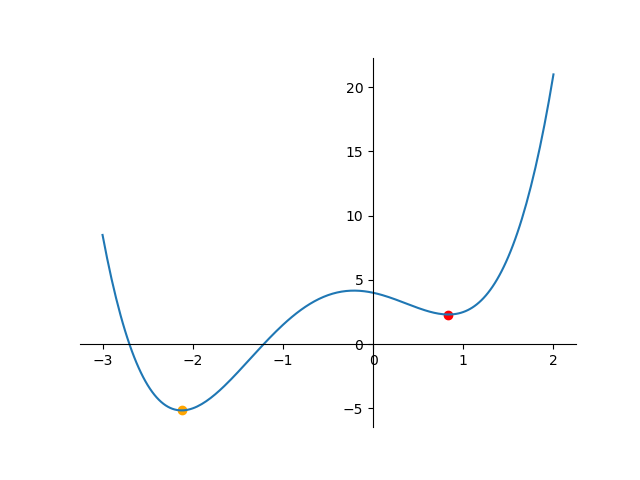

In [10]:
g = lambda x: (x - 1)**2 * (x + 2)**2 + 5*x/2
fig, ax = plt.subplots()
X = np.linspace(-3,2,201)
ax.plot(X,g(X))
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

# Here, scipy.optimize.minimize_scalar will give the "wrong" local minimizer:
res = scipy.optimize.minimize_scalar(g)
plt.scatter(res.x, g(res.x),color='red')
print(res)

# If we give an initial bracket, it will also fund eth other local minimum:
res2 = scipy.optimize.minimize_scalar(g, bracket = (-3,-1))
plt.scatter(res2.x, g(res2.x),color='orange')
print(res2)


We can also find extrema in a close interval:

 message: Solution found.
 success: True
  status: 0
     fun: 1.5000387454898165
       x: -0.9999940391390134
     nit: 25
    nfev: 25


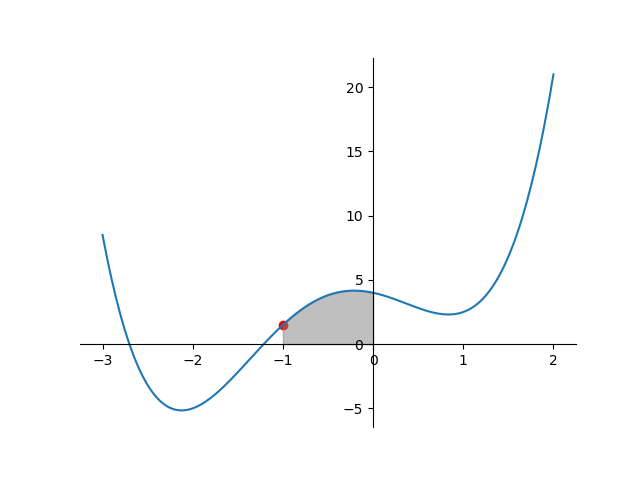

In [11]:
g = lambda x: (x - 1)**2 * (x + 2)**2 + 5*x/2
fig, ax = plt.subplots()
X = np.linspace(-3,2,201)
ax.plot(X,g(X))
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

# Here, scipy.optimize.minimize_scalar will give the "wrong" local minimizer:
res = scipy.optimize.minimize_scalar(g,bounds=(-1,0))
plt.scatter(res.x, g(res.x),color='red')
X = np.linspace(-1,0,101)
plt.fill_between(X,g(X),color='grey', alpha = 0.5)
print(res)


### Example 

Today we saw *numeric differentation* and next week we will see *symbolic differentiation*. As a segue, we will end today with something that lies in between the two. This algorithm is called *forward mode automatic differentiation*, but don't let the name scare you, it is actually quite a simple algorithm!

To define forward mode automatic differentiation, we must first define a new kind of number. We call this number system the **dual numbers**. We can construct the **dual numbers** from the reals by adding a new *infinitesimal* object. That is, we add a new number called $\epsilon$ that is smaller than all other real numbers. 

After adding this number to the reals, we may express every dual number in terms of its real part and its infinitesimal part. Addition works exactly as in the complex numbers (we just add each component). However, multiplication is more interesting. 

To multiple two dual numbers $z=a+b\epsilon$ and $w=c+d\epsilon$, we add the following rule: $\epsilon^2=0$. We then have the following:
$$zw=(a+b\epsilon)(c+d\epsilon)=ac+ad\epsilon +bc\epsilon +bd\epsilon^2=ac+(ad+bc)\epsilon$$

### Automatic differentiation

Now, for the algorithm: Given a function $f:\mathbb{R}\rightarrow\mathbb{R}$, consider $f(x+\epsilon)$. 

**Fact:** Once we expand $f(x+\epsilon)$ into the form $a+b\epsilon$, $a=f(x)$ and $b=f'(x)$. 

**Example:** Let $f(x)=x^2$, then 
$$f(x+\epsilon)=(x+\epsilon)^2=x^2+2x\epsilon+\epsilon^2=x^2+2x\epsilon$$

We see that the real part is exactly the original function and the infinitesimal part is exactly the derivative.

### The Dual numbers

In order to use this idea, we must introduce the dual numbers to Python! We can do this by defining a new class!

In [ ]:
class Dual:
    def __init__(self,real,inf):
        self.real = real
        self.inf = inf
    def __repr__(self):
        return f"{self.real} + {self.inf}eps"
    def __add__(self,other):
        real = self.real + other.real
        inf = self.inf + other.inf
        return Dual(real,inf)
    def __mul__(self,other):
        real = self.real*other.real
        inf = self.real*other.inf + other.real*self.inf
        return Dual(real,inf)

a = Dual(1,2)
b = Dual(3,4)
def f(x):
    return x*x

def deriv(f,x):
    return f(Dual(x,1)).inf

print(deriv(f,6))